In [1]:
%%bash
mkdir storm_mode
cd storm_mode
wget -nc -q https://raw.githubusercontent.com/ahaberlie/unidata-workshop-2018/refs/heads/master/workshop/data/training/sample_train_data.csv
wget -nc -q https://raw.githubusercontent.com/ahaberlie/unidata-workshop-2018/refs/heads/master/workshop/data/training/sample_test_data.csv

# L7 - Scikit-Learn - Decision Trees

Directions:

1. Please rename the file by clicking on “LX-First-Last.ipynb” where X is the lab number, and replace First and Last with your first and last name.

2. Click File -> Save to make sure your most recent edits are saved.

3. In the upper right hand corner of the screen, click on “Share”. Click on “Restricted” and change it to “Anyone with the link”. Make sure you also share it with `ahaberlie1@gmail.com`.

4. Copy the link and submit it on Blackboard. Make sure you follow these steps completely, or I will be unable to grade your work.

### Overview

This lab will help you understand scikit-learn and its decision tree capabilities. We will walk through some examples of how scikit-learn can help solve Geoscience problems. Periodically, I will 1) ask you to either repeat the demonstrated code in a slightly different way; or 2) ask you to combine two or more techniques to solve a problem.

You can use generative AI to help answer these problems. **The answer should still be in your own words.** Think of the generative AI descriptions as those from a book. You still have to cite your source and you cannot plagiarize directly from the source. For every question that you used generative AI for help, please reference the generative AI you used and what your prompt or prompts were.

However, it is crucial that you understand the code well enough to effectively use generative AI tools that are likely to be widely available and recommended for use at many organizations. Although they are improving at an incredible rate, they still produce bugs, especially with domain-specific and complex problems. Make sure that you verify the answers before putting them in your own words.

**Model performance assessment**

When assessing model performance, we typically separate the sample data into three subsets. Think of your own experiences preparing for an exam as motivation for the subsets:

1. Training data - this is what the machine learning approach uses to generate a model. Similar to lectures/homework/assignments/etc. in class.
2. Validation data - this is what is used to do quick "spot checks" on the model and help determine optimal model settings. This is similar to doing a practice quiz and learning what you need to focus on before the exam.
3. Testing data - this is what is used to test the performance of the model. This is similar to finally taking the exam.

I have provided you with the training and testing datasets. We will also generate the validation dataset below:

In [2]:
import pandas as pd
import numpy as np

np.random.seed(4)

def custom_train_split(df, val_year_start=2012):
    '''Takes a pandas DataFrame with training data
    and sorts it into two subsets: 1) training data before
    and including `val_year_start`; and 2) validation data
    after `val_year_start`

    Parameters:
        df: pandas DataFrame
            Original training data.
        val_year_start: int
            Year that defines the split between training and
            validation data. Default 2011. Must be between
            2006 and 2012.

    Returns:
        (df_train, df_test): tuple
            DataFrames split into training and testing data
    '''
    df_train = df[df['datetime'].dt.year < val_year_start]
    df_val = df[df['datetime'].dt.year >= val_year_start]

    return df_train, df_val

def convert_to_numpy(df, remove_cols, binary_label='MCS',
                     label_col='label_name'):
    '''Converts DataFrame to machine learning friendly
    format by removing non-numeric columns and columns
    provided by `remove_cols`.

    Parameters:
        df: pandas DataFrame
            Original DataFrame with all columns
        remove_cols: list
            Other columns to remove that are numeric.
        binary_label: str
            If not None, convert label to 1 if `label_cols`
            is equal to `binary_label` in `df`.
        label_col: str
            Column name in `df` that contains original labels.

    Returns:
        npy_data: numpy ndarray
            Converted data ready for the training process.
    '''
    df_ = df.copy()

    numeric_cols = df_.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in remove_cols]

    print(numeric_cols)

    if binary_label is not None:
        df_[binary_label] = df_[label_col] == binary_label

    df_x = df_[numeric_cols].to_numpy()
    df_y = df_[binary_label].to_numpy()

    return df_x, df_y, numeric_cols

df_train = pd.read_csv("storm_mode/sample_train_data.csv")
df_test = pd.read_csv("storm_mode/sample_test_data.csv")

df_train['datetime'] = pd.to_datetime(df_train['datetime'])
df_train = df_train.sort_values(by='datetime')
df_test['datetime'] = pd.to_datetime(df_test['datetime'])

df_train, df_val = custom_train_split(df_train)

rem_cols = ['index', 'label', 'label1']

train_x, train_y, num_cols = convert_to_numpy(df_train, remove_cols=rem_cols)
val_x, val_y, num_cols = convert_to_numpy(df_val, remove_cols=rem_cols)
test_x, test_y, num_cols = convert_to_numpy(df_test, remove_cols=rem_cols)

print(train_x.shape, train_y.shape, train_x.dtype)
print(val_x.shape, val_y.shape, val_x.dtype)
print(test_x.shape, test_y.shape, test_x.dtype)

['mean_intensity', 'solidity', 'intensity_variance', 'intense_convection_ratio', 'convection_stratiform_ratio', 'area', 'convection_area', 'max_intensity', 'minor_axis_length', 'intense_area', 'eccentricity', 'convex_area', 'intense_stratiform_ratio', 'major_axis_length', 'minor_major_ratio', 'xmax', 'xmin', 'ymax', 'ymin']
['mean_intensity', 'solidity', 'intensity_variance', 'intense_convection_ratio', 'convection_stratiform_ratio', 'area', 'convection_area', 'max_intensity', 'minor_axis_length', 'intense_area', 'eccentricity', 'convex_area', 'intense_stratiform_ratio', 'major_axis_length', 'minor_major_ratio', 'xmax', 'xmin', 'ymax', 'ymin']
['mean_intensity', 'solidity', 'intensity_variance', 'intense_convection_ratio', 'convection_stratiform_ratio', 'area', 'convection_area', 'max_intensity', 'minor_axis_length', 'intense_area', 'eccentricity', 'convex_area', 'intense_stratiform_ratio', 'major_axis_length', 'minor_major_ratio', 'xmax', 'xmin', 'ymax', 'ymin']
(350, 19) (350,) float

### Problem 1

Answer in the markdown: Assess the following decision tree in your own words. What is the performance of this tree? What are some caveats associated with this performance?

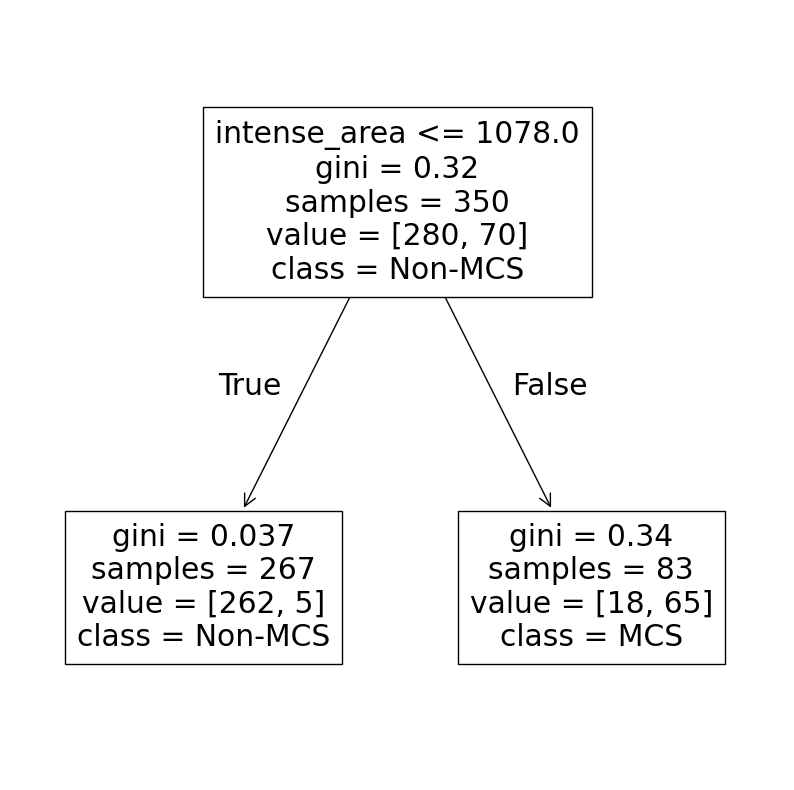

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 10, 10

from sklearn.tree import DecisionTreeClassifier, plot_tree

CART = DecisionTreeClassifier(max_depth=1).fit(X=train_x, y=train_y)

plot_tree(CART, feature_names=num_cols, class_names=['Non-MCS', 'MCS'])
plt.show()

### Problem 2

Answer in the markdown: Using the validation dataset, the following example shows two possible decision tree configurations and the F-score for each case. In your own words, assess the performance of each case and identify which case you should choose. What is the difference between the two trees?

In [4]:
from sklearn.metrics import f1_score

for case_num, min_samples_split in enumerate([2, 100]):

    case_ = DecisionTreeClassifier(
        min_samples_split=min_samples_split,
        random_state=100
    ).fit(X=train_x, y=train_y)

    case_y = case_.predict(val_x)
    case_f = f1_score(val_y, case_y, average='binary')

    print(f"Case {case_num+1} f-score (min_samples_split={min_samples_split}):", case_f)

Case 1 f-score (min_samples_split=2): 0.6666666666666666
Case 2 f-score (min_samples_split=100): 0.8181818181818182


### Problem 3

Answer in the markdown: Using the validation dataset, the following example shows two possible decision tree configurations and the F-score for each case. In your own words, assess the performance of each case and identify which case you should choose. What is the difference between the two trees?

In [5]:
from sklearn.metrics import f1_score

for case_num, criterion in enumerate(['gini', 'entropy']):

    case_ = DecisionTreeClassifier(
        criterion=criterion,
        random_state=100
    ).fit(X=train_x, y=train_y)

    case_y = case_.predict(val_x)
    case_f = f1_score(val_y, case_y, average='binary')

    print(f"Case {case_num+1} f-score (criterion={criterion}):", case_f)

Case 1 f-score (criterion=gini): 0.6666666666666666
Case 2 f-score (criterion=entropy): 0.8421052631578947


### Problem 4

**Automated model selection**

`sklearn` has an automated way to test out many different model configurations: `GridSearchCV`. This class requires you to think about the following options:

1. `estimator`: this is your untrained `DecisionTreeClassifier` instance. Do not run `fit`.

2. `param_grid`: this is a dictionary with the parameter names and all the possible values you want to test with that parameter.

3. `scoring`: this defines how `GridSearchCV` will determine the "best performing" model on validation data.

4. `cv`: this is how you will separate the training and validation data. In some cases, it might be appropriate to have sklearn handle this with an approach that randomly removes 10% of the data in `k` different ways. In our case, we will use a predefined split, since it is important to examine "new" data that has temporal independence.

This approach essentially recreates the loops we did in the previous problems. You just have to define the possible values for each parameter.

The first step is to look up the documentation for the model you are using. We are using a [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html). On that page you will see `Parameters` along with several different names of parameters and descriptions. You can try different ranges of numbers that make sense for each parameter. These need to be put in a `dictionary`.

For this case, we will test the following values to see which combination works best:

1. test `criterion` of `gini` (we calculated this earlier) or `entropy`
2. test `max_depth` of None (no limit), 2, 4, 6, 8, and 12
3. test `min_samples_split` of 2, 5, 10, and 20
4. test `min_samples_leaf` of 1, 2, 5, and 10

We can use `ParameterGrid` to see all the different combinations.

Answer in the markdown in your own words:

Why are there 192 rows?

Give an example of manually creating a DecisionTreeClassifier model based on the parameters in row 50 (index 49).

In [6]:
import pandas as pd
from sklearn.model_selection import ParameterGrid

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 2, 4, 6, 8, 12],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
}

df_params = pd.DataFrame(list(ParameterGrid(param_grid)))
print(df_params.shape)
display(df_params)

(192, 4)


,criterion,max_depth,min_samples_leaf,min_samples_split
0,gini,NaN,1,2
1,gini,NaN,1,5
2,gini,NaN,1,10
3,gini,NaN,1,20
4,gini,NaN,2,2
...,...,...,...,...
187,entropy,12.0,5,20
188,entropy,12.0,10,2
189,entropy,12.0,10,5
190,entropy,12.0,10,10


Next, we will define the split used to decide what data are supplied to the training process and what data are supplied for the validation process. Since we already have those subsets, we will use the `PredefinedSplit` approach.

The model selection approach, by default, assumes that we have one subset of feature vector information (i.e., `train_x` and `val_x`) as well as one subset of label information (i.e., `train_y` and `val_y`).

The best way to combine these two subsets is to use `concatenate` from numpy. We will use this to "attach" `val` on to the end of `train`. As long as we know *where* this happens, it is easy to define how to tell the model selection step how to split the data.

First, here is a smaller example:

`trainx` is an ndarray of 2 feature vectors with 3 features and `trainy` is a ndarray of 2 labels associated with those feature vectors. Similarly, `valx` and `valy` are the same, except for one sample.

When you run the `concatenate` method, you see the result is just a combination of the `train` and `val` subsets.

If you wanted to tell the model selection approach that these indices were `train` with a value of `-1` (not in the 'val' set) and `val` with a value of 0 (in the `val` set), you would define `split` as you do below. The model selection approach will keep all indices of `0` off to the side and use all indices of `-1` to train each model variant. Each model variant will tested with the `0` indices (the validation data), and the best performing model on those data will be selected.


In [7]:
trainx = [[1, 2, 3], [3, 2, 1]]
trainy = [0, 1]

valx = [[2, 2, 2]]
valy = [1]

X = np.concatenate([trainx, valx])
y = np.concatenate([trainy, valy])

split = [-1, -1, 0]

print("X =", X)
print("Y = ", y)
print("split = ", split)



X = [[1 2 3]
 [3 2 1]
 [2 2 2]]
Y =  [0 1 1]
split =  [-1, -1, 0]


Here is the full concatenation:

In [8]:
combined_X = np.concatenate([train_x, val_x])
combined_y = np.concatenate([train_y, val_y])



We know that the `train_x` data end at index `len(train_x)`, so we can easily create the `-1` and `0` arrays using a number of approaches, for example:

In [9]:
train_idx = [-1.0] * train_x.shape[0]
val_idx = [0.0] * val_x.shape[0]

splits = np.concatenate([train_idx, val_idx])

splits

array([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1

We then pass this array into `PredefinedSplit`

In [10]:
from sklearn.model_selection import PredefinedSplit

ps = PredefinedSplit(splits)

for i, (train_index, val_index) in enumerate(ps.split()):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Val:  index={val_index}")


Fold 0:
  Train: index=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240

Finally, we build a basic `DecisionTreeClassifier` and pass the required information into `GridSearchCV`. The new code here is:

1. `make_scorer`: a wrapper around the f1_score we used before.
2. `refit`: if True, retrain the best performing model and provide it as `best_estimator_`.


In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

dt = DecisionTreeClassifier(random_state=100)

grid = GridSearchCV(estimator=dt, param_grid=param_grid,
                    scoring=make_scorer(f1_score, average="binary"),
                    cv=ps, refit=True, verbose=1, return_train_score=True)

grid.fit(combined_X, combined_y)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_dt = grid.best_estimator_

Fitting 1 folds for each of 192 candidates, totalling 192 fits
Best params: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1: 0.9


### Problem 5

Now, compare the results on the validation data to those on the testing data.

Calculate TP, FP, FN, TN, recall and precision for both testing/validation using the plots below (confusion matrix). Verify that the F score is correct.

Answer in the markdown: Do the validation data results match with the testing data? Why or why not? What do you think this suggests about the ability of the model to generalize to new, unseen years?

In [12]:
val_y.shape

(49,)

For {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2} the F score for val data is 0.9473684210526315
For {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2} the F score for val data is 0.8108108108108109


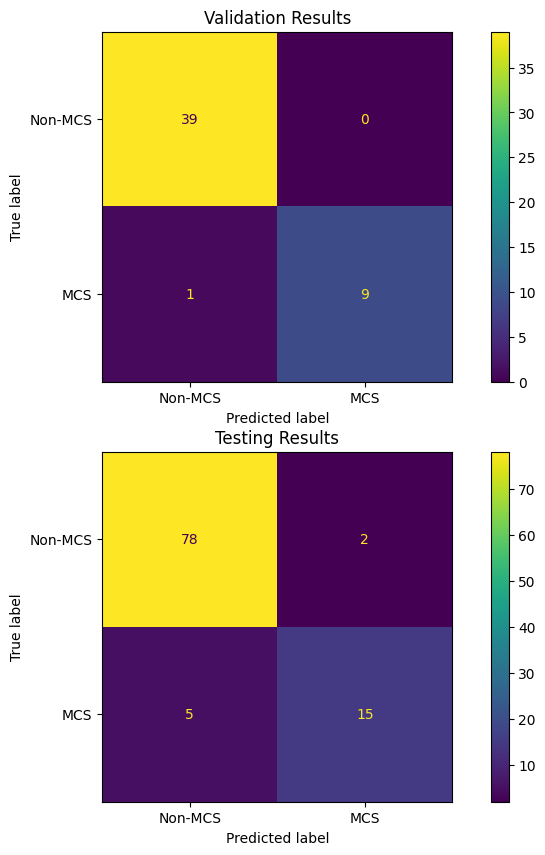

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 10, 10

preds_val = best_dt.predict(val_x)
fscore_val = f1_score(val_y, preds_val, average='binary')
print("For", grid.best_params_, "the F score for val data is", fscore_val)

preds_test = best_dt.predict(test_x)
fscore_test = f1_score(test_y, preds_test, average='binary')
print("For", grid.best_params_, "the F score for val data is", fscore_test)

ax = plt.subplot(2, 1, 1)
ax.set_title("Validation Results")

cm = confusion_matrix(val_y, preds_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-MCS', 'MCS'])
disp.plot(ax=ax)

ax1 = plt.subplot(2, 1, 2)
ax1.set_title("Testing Results")

cm = confusion_matrix(test_y, preds_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-MCS', 'MCS'])
disp.plot(ax=ax1)